# PDC Final Lab Exam — DNA K-mer Mining Pipeline
**Framework:** Apache Spark (PySpark)  
**Topic:** Distributed DNA Sequence Analysis — GC Content, K-mer Frequencies, Sequence Length Distribution  
**Dataset:** NCBI RefSeq Bacterial Genomes (public FASTA files)  
**Pipeline:** Ingest → Clean/Validate → Transform/Feature Extraction → Distributed Analysis → Results


## Step 0 — Install & Import Dependencies

In [1]:
# Install required packages (run once)
!pip install pyspark biopython matplotlib seaborn pandas numpy

import os
import re
import urllib.request
import gzip
import shutil
from collections import Counter

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns

from pyspark.sql import SparkSession
from pyspark.sql import functions as F
from pyspark.sql.types import (
    StructType, StructField, StringType, IntegerType,
    FloatType, ArrayType, LongType
)
from pyspark.sql.window import Window

print("✅ All imports successful")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.2/3.2 MB 9.7 MB/s eta 0:00:00
✅ All imports successful


## Step 1 — Initialize Spark Session

In [2]:
spark = SparkSession.builder \
    .appName("PDC_DNA_Kmer_Pipeline") \
    .master("local[*]") \
    .config("spark.driver.memory", "4g") \
    .config("spark.executor.memory", "4g") \
    .config("spark.sql.shuffle.partitions", "8") \
    .config("spark.default.parallelism", "8") \
    .getOrCreate()

spark.sparkContext.setLogLevel("WARN")

print(f"✅ Spark version: {spark.version}")
print(f"✅ Partitions: {spark.conf.get('spark.sql.shuffle.partitions')}")
print(f"✅ Master: {spark.sparkContext.master}")

✅ Spark version: 4.0.2
✅ Partitions: 8
✅ Master: local[*]


## Step 2 — Dataset Download

**Source:** NCBI RefSeq — *E. coli* K-12 complete genome (public domain)  
**URL:** https://ftp.ncbi.nlm.nih.gov/genomes/all/GCF/000/005/845/GCF_000005845.2_ASM584v2/  
**File type:** FASTA (.fna.gz)  
**Approx size:** ~4.6 MB compressed / ~14 MB uncompressed  
**License:** NCBI public domain data

In [3]:
# Create data directory
os.makedirs("data", exist_ok=True)
os.makedirs("results", exist_ok=True)

# ---------------------------------------------------------------
# Multiple organisms for comparative analysis
# ---------------------------------------------------------------
DATASETS = {
    "E_coli_K12": {
        "url": "https://ftp.ncbi.nlm.nih.gov/genomes/all/GCF/000/005/845/"
                "GCF_000005845.2_ASM584v2/"
                "GCF_000005845.2_ASM584v2_genomic.fna.gz",
        "gz":  "data/ecoli_k12.fna.gz",
        "fna": "data/ecoli_k12.fna"
    },
    "B_subtilis": {
        "url": "https://ftp.ncbi.nlm.nih.gov/genomes/all/GCF/000/009/045/"
                "GCF_000009045.1_ASM904v1/"
                "GCF_000009045.1_ASM904v1_genomic.fna.gz",
        "gz":  "data/bsubtilis.fna.gz",
        "fna": "data/bsubtilis.fna"
    },
    "S_aureus": {
        "url": "https://ftp.ncbi.nlm.nih.gov/genomes/all/GCF/000/013/425/"
                "GCF_000013425.1_ASM1342v1/"
                "GCF_000013425.1_ASM1342v1_genomic.fna.gz",
        "gz":  "data/saureus.fna.gz",
        "fna": "data/saureus.fna"
    }
}

def download_and_decompress(name, info):
    """Download .fna.gz and decompress to .fna"""
    if os.path.exists(info["fna"]):
        print(f"⏭  {name}: already downloaded, skipping")
        return
    print(f"⬇  Downloading {name} ...")
    urllib.request.urlretrieve(info["url"], info["gz"])
    print(f"📦 Decompressing {name} ...")
    with gzip.open(info["gz"], 'rb') as f_in:
        with open(info["fna"], 'wb') as f_out:
            shutil.copyfileobj(f_in, f_out)
    os.remove(info["gz"])
    size_mb = os.path.getsize(info["fna"]) / 1e6
    print(f"✅ {name}: {size_mb:.2f} MB")

for name, info in DATASETS.items():
    download_and_decompress(name, info)

print("\n✅ All datasets ready")

⬇  Downloading E_coli_K12 ...
📦 Decompressing E_coli_K12 ...
✅ E_coli_K12: 4.70 MB
⬇  Downloading B_subtilis ...
📦 Decompressing B_subtilis ...
✅ B_subtilis: 4.27 MB
⬇  Downloading S_aureus ...
📦 Decompressing S_aureus ...
✅ S_aureus: 2.86 MB

✅ All datasets ready


## Step 3 — FASTA Parser → Spark DataFrame (Ingest)

Parse raw FASTA files → structured records with sequence metadata.

In [4]:
def parse_fasta(filepath, organism_name):
    """
    Parse FASTA file into list of dicts.
    Returns: [{organism, seq_id, description, sequence}]
    """
    records = []
    current_id = None
    current_desc = ""
    current_seq = []

    with open(filepath, 'r') as f:
        for line in f:
            line = line.strip()
            if not line:
                continue
            if line.startswith('>'):
                # Save previous record
                if current_id:
                    records.append({
                        "organism":    organism_name,
                        "seq_id":      current_id,
                        "description": current_desc,
                        "sequence":    ''.join(current_seq).upper()
                    })
                # Start new record
                header = line[1:]
                parts = header.split(None, 1)
                current_id   = parts[0]
                current_desc = parts[1] if len(parts) > 1 else ""
                current_seq  = []
            else:
                current_seq.append(line)

    # Last record
    if current_id:
        records.append({
            "organism":    organism_name,
            "seq_id":      current_id,
            "description": current_desc,
            "sequence":    ''.join(current_seq).upper()
        })

    return records

# Parse all organisms
all_records = []
for name, info in DATASETS.items():
    recs = parse_fasta(info["fna"], name)
    all_records.extend(recs)
    print(f"  {name}: {len(recs)} sequence(s)")

print(f"\n✅ Total records parsed: {len(all_records)}")

  E_coli_K12: 1 sequence(s)
  B_subtilis: 1 sequence(s)
  S_aureus: 1 sequence(s)

✅ Total records parsed: 3


In [5]:
# Define schema explicitly for Spark
schema = StructType([
    StructField("organism",    StringType(), False),
    StructField("seq_id",      StringType(), False),
    StructField("description", StringType(), True),
    StructField("sequence",    StringType(), False),
])

# Create Spark DataFrame with partitioning for distributed processing
raw_df = spark.createDataFrame(all_records, schema=schema) \
              .repartition(8, "organism")   # partition by organism = distributed ops

raw_df.cache()  # Cache — reused multiple times downstream

print(f"✅ Spark DataFrame created")
print(f"   Partitions: {raw_df.rdd.getNumPartitions()}")
raw_df.show(5, truncate=80)

✅ Spark DataFrame created
   Partitions: 8
+----------+-----------+-------------------------------------------------------------------------+--------------------------------------------------------------------------------+
|  organism|     seq_id|                                                              description|                                                                        sequence|
+----------+-----------+-------------------------------------------------------------------------+--------------------------------------------------------------------------------+
|  S_aureus|NC_007795.1|Staphylococcus aureus subsp. aureus NCTC 8325 chromosome, complete genome|CGATTAAAGATAGAAATACACGATGCGAGCAATCAAATTTCATAACATCACCATGAGTTTGGTCCGAAGCATGAGTG...|
|E_coli_K12|NC_000913.3|               Escherichia coli str. K-12 substr. MG1655, complete genome|AGCTTTTCATTCTGACTGCAACGGGCAATATGTCTCTGTGTGGATTAAAAAAAGAGTGTCTGATAGCAGCTTCTGAA...|
|B_subtilis|NC_000964.3|               Bacillus subtilis 

## Step 4 — Clean & Validate

In [7]:
# ── UDF: count ambiguous bases (N, R, Y, etc.) ──────────────────
count_ambiguous_udf = F.udf(
    lambda seq: int(sum(1 for b in seq if b not in 'ACGT')) if seq else 0,
    IntegerType()
)

cleaned_df = raw_df \
    .withColumn("seq_length",         F.length("sequence")) \
    .withColumn("ambiguous_count",    count_ambiguous_udf(F.col("sequence"))) \
    .withColumn("ambiguous_pct",
                F.round(F.col("ambiguous_count") / F.col("seq_length") * 100, 4)) \
    .filter(F.col("seq_length") > 100) \
    .filter(F.col("ambiguous_pct") < 5.0) \
    .withColumn("sequence",
                F.regexp_replace("sequence", "[^ACGT]", ""))

cleaned_df.cache()

print("✅ Cleaning done")
print(f"   Before: {raw_df.count()} | After: {cleaned_df.count()} sequences")
cleaned_df.select("organism","seq_id","seq_length","ambiguous_count","ambiguous_pct") \
          .show(10)

✅ Cleaning done
   Before: 3 | After: 3 sequences
+----------+-----------+----------+---------------+-------------+
|  organism|     seq_id|seq_length|ambiguous_count|ambiguous_pct|
+----------+-----------+----------+---------------+-------------+
|  S_aureus|NC_007795.1|   2821361|              1|          0.0|
|E_coli_K12|NC_000913.3|   4641652|              0|          0.0|
|B_subtilis|NC_000964.3|   4215606|              0|          0.0|
+----------+-----------+----------+---------------+-------------+



## Step 5 — Distributed Feature Extraction

### 5a. GC Content per Sequence

In [8]:
# UDF: GC content
@F.udf(FloatType())
def gc_content_udf(seq):
    if not seq or len(seq) == 0:
        return 0.0
    gc = seq.count('G') + seq.count('C')
    return round(gc / len(seq) * 100, 4)

# UDF: individual nucleotide counts
@F.udf(ArrayType(IntegerType()))
def nucleotide_counts_udf(seq):
    if not seq:
        return [0, 0, 0, 0]
    return [seq.count('A'), seq.count('C'), seq.count('G'), seq.count('T')]

features_df = cleaned_df \
    .withColumn("gc_content",       gc_content_udf(F.col("sequence"))) \
    .withColumn("nuc_counts",       nucleotide_counts_udf(F.col("sequence"))) \
    .withColumn("count_A",          F.col("nuc_counts")[0]) \
    .withColumn("count_C",          F.col("nuc_counts")[1]) \
    .withColumn("count_G",          F.col("nuc_counts")[2]) \
    .withColumn("count_T",          F.col("nuc_counts")[3]) \
    .drop("nuc_counts")

features_df.cache()

print("✅ GC content + nucleotide counts computed")
features_df.select(
    "organism","seq_id","seq_length","gc_content",
    "count_A","count_C","count_G","count_T"
).show(10)

✅ GC content + nucleotide counts computed
+----------+-----------+----------+----------+-------+-------+-------+-------+
|  organism|     seq_id|seq_length|gc_content|count_A|count_C|count_G|count_T|
+----------+-----------+----------+----------+-------+-------+-------+-------+
|  S_aureus|NC_007795.1|   2821361|   32.8683| 938713| 465832| 461500| 955315|
|E_coli_K12|NC_000913.3|   4641652|   50.7907|1142742|1180091|1177437|1141382|
|B_subtilis|NC_000964.3|   4215606|   43.5144|1188073| 919284| 915112|1193137|
+----------+-----------+----------+----------+-------+-------+-------+-------+



### 5b. K-mer Frequency Computation (Distributed)

**k=4** (tetranucleotides) — 256 possible kmers, biologically meaningful for motif detection.

In [9]:
K = 4  # kmer length

# UDF: returns list of (kmer, count) pairs
@F.udf(ArrayType(StructType([
    StructField("kmer",  StringType(),  False),
    StructField("count", IntegerType(), False)
])))
def extract_kmers_udf(seq):
    if not seq or len(seq) < K:
        return []
    # Slide window across sequence
    counter = Counter(seq[i:i+K] for i in range(len(seq) - K + 1))
    # Only canonical ACGT kmers
    valid = {k: v for k, v in counter.items() if re.fullmatch(r'[ACGT]+', k)}
    return [(k, v) for k, v in valid.items()]

# Apply UDF → explode to one row per kmer per sequence
kmer_raw_df = features_df \
    .withColumn("kmers", extract_kmers_udf(F.col("sequence"))) \
    .withColumn("kmer_entry", F.explode("kmers")) \
    .withColumn("kmer",       F.col("kmer_entry.kmer")) \
    .withColumn("kmer_count", F.col("kmer_entry.count")) \
    .drop("kmers", "kmer_entry", "sequence")  # drop raw sequence to save memory

kmer_raw_df.cache()

print(f"✅ K-mer extraction done (k={K})")
print(f"   Total kmer rows: {kmer_raw_df.count():,}")
kmer_raw_df.select("organism","seq_id","kmer","kmer_count").show(10)

✅ K-mer extraction done (k=4)
   Total kmer rows: 768
+--------+-----------+----+----------+
|organism|     seq_id|kmer|kmer_count|
+--------+-----------+----+----------+
|S_aureus|NC_007795.1|CGAT|      8804|
|S_aureus|NC_007795.1|GATT|     18454|
|S_aureus|NC_007795.1|ATTA|     33958|
|S_aureus|NC_007795.1|TTAA|     36886|
|S_aureus|NC_007795.1|TAAA|     38900|
|S_aureus|NC_007795.1|AAAG|     21087|
|S_aureus|NC_007795.1|AAGA|     17674|
|S_aureus|NC_007795.1|AGAT|     14365|
|S_aureus|NC_007795.1|GATA|     16644|
|S_aureus|NC_007795.1|ATAG|     11190|
+--------+-----------+----+----------+
only showing top 10 rows


In [10]:
# ── Aggregate: total kmer frequency per organism ─────────────────
kmer_organism_df = kmer_raw_df \
    .groupBy("organism", "kmer") \
    .agg(F.sum("kmer_count").alias("total_count")) \
    .withColumn("rank",
                F.rank().over(
                    Window.partitionBy("organism")
                          .orderBy(F.desc("total_count"))
                ))

print("✅ K-mer aggregation per organism done")
kmer_organism_df.filter(F.col("rank") <= 5).orderBy("organism","rank").show(20)

✅ K-mer aggregation per organism done
+----------+----+-----------+----+
|  organism|kmer|total_count|rank|
+----------+----+-----------+----+
|B_subtilis|TTTT|      62136|   1|
|B_subtilis|AAAA|      61272|   2|
|B_subtilis|TTTC|      37473|   3|
|B_subtilis|GAAA|      36995|   4|
|B_subtilis|ATTT|      36598|   5|
|E_coli_K12|CAGC|      37512|   1|
|E_coli_K12|GCTG|      36536|   2|
|E_coli_K12|TTTT|      35619|   3|
|E_coli_K12|CGCC|      35175|   4|
|E_coli_K12|AAAA|      35148|   5|
|  S_aureus|TTTT|      43000|   1|
|  S_aureus|AAAA|      42310|   2|
|  S_aureus|ATTT|      41797|   3|
|  S_aureus|AAAT|      40907|   4|
|  S_aureus|TTTA|      39598|   5|
+----------+----+-----------+----+



## Step 6 — Distributed Analysis & Summary Tables

In [11]:
# ── Table 1: Per-organism genome summary ─────────────────────────
summary_df = features_df.groupBy("organism").agg(
    F.count("seq_id")                   .alias("num_sequences"),
    F.sum("seq_length")                 .alias("total_bases"),
    F.round(F.mean("gc_content"), 3)    .alias("mean_gc_pct"),
    F.round(F.stddev("gc_content"), 3)  .alias("stddev_gc_pct"),
    F.min("seq_length")                 .alias("min_seq_len"),
    F.max("seq_length")                 .alias("max_seq_len"),
    F.round(F.mean("seq_length"), 0)    .alias("mean_seq_len")
).orderBy("organism")

print("=" * 70)
print("TABLE 1 — Genome Summary Statistics per Organism")
print("=" * 70)
summary_df.show(truncate=False)

# Save to CSV
summary_pd = summary_df.toPandas()
summary_pd.to_csv("results/table1_genome_summary.csv", index=False)
print("✅ Saved: results/table1_genome_summary.csv")

TABLE 1 — Genome Summary Statistics per Organism
+----------+-------------+-----------+-----------+-------------+-----------+-----------+------------+
|organism  |num_sequences|total_bases|mean_gc_pct|stddev_gc_pct|min_seq_len|max_seq_len|mean_seq_len|
+----------+-------------+-----------+-----------+-------------+-----------+-----------+------------+
|B_subtilis|1            |4215606    |43.514     |NULL         |4215606    |4215606    |4215606.0   |
|E_coli_K12|1            |4641652    |50.791     |NULL         |4641652    |4641652    |4641652.0   |
|S_aureus  |1            |2821361    |32.868     |NULL         |2821361    |2821361    |2821361.0   |
+----------+-------------+-----------+-----------+-------------+-----------+-----------+------------+

✅ Saved: results/table1_genome_summary.csv


In [12]:
# ── Table 2: Top 10 k-mers per organism ──────────────────────────
top_kmers_df = kmer_organism_df \
    .filter(F.col("rank") <= 10) \
    .orderBy("organism", "rank")

print("=" * 70)
print(f"TABLE 2 — Top 10 {K}-mers per Organism")
print("=" * 70)
top_kmers_df.show(40, truncate=False)

top_kmers_pd = top_kmers_df.toPandas()
top_kmers_pd.to_csv("results/table2_top_kmers.csv", index=False)
print("✅ Saved: results/table2_top_kmers.csv")

TABLE 2 — Top 10 4-mers per Organism
+----------+----+-----------+----+
|organism  |kmer|total_count|rank|
+----------+----+-----------+----+
|B_subtilis|TTTT|62136      |1   |
|B_subtilis|AAAA|61272      |2   |
|B_subtilis|TTTC|37473      |3   |
|B_subtilis|GAAA|36995      |4   |
|B_subtilis|ATTT|36598      |5   |
|B_subtilis|AAAT|36352      |6   |
|B_subtilis|CTTT|34485      |7   |
|B_subtilis|AAAG|34039      |8   |
|B_subtilis|TTCA|33823      |9   |
|B_subtilis|TGAA|33532      |10  |
|E_coli_K12|CAGC|37512      |1   |
|E_coli_K12|GCTG|36536      |2   |
|E_coli_K12|TTTT|35619      |3   |
|E_coli_K12|CGCC|35175      |4   |
|E_coli_K12|AAAA|35148      |5   |
|E_coli_K12|GCGC|35090      |6   |
|E_coli_K12|GGCG|34498      |7   |
|E_coli_K12|CCAG|34277      |8   |
|E_coli_K12|CTGG|33766      |9   |
|E_coli_K12|GCCA|31820      |10  |
|S_aureus  |TTTT|43000      |1   |
|S_aureus  |AAAA|42310      |2   |
|S_aureus  |ATTT|41797      |3   |
|S_aureus  |AAAT|40907      |4   |
|S_aureus  |TTTA|3

In [13]:
# ── Table 3: Nucleotide composition per organism ──────────────────
nuc_df = features_df.groupBy("organism").agg(
    F.sum("count_A").alias("total_A"),
    F.sum("count_C").alias("total_C"),
    F.sum("count_G").alias("total_G"),
    F.sum("count_T").alias("total_T"),
)

nuc_df = nuc_df.withColumn("total",
    F.col("total_A") + F.col("total_C") + F.col("total_G") + F.col("total_T")
).withColumn("pct_A", F.round(F.col("total_A")/F.col("total")*100, 2)) \
 .withColumn("pct_C", F.round(F.col("total_C")/F.col("total")*100, 2)) \
 .withColumn("pct_G", F.round(F.col("total_G")/F.col("total")*100, 2)) \
 .withColumn("pct_T", F.round(F.col("total_T")/F.col("total")*100, 2))

print("=" * 70)
print("TABLE 3 — Nucleotide Composition per Organism (%)")
print("=" * 70)
nuc_df.select("organism","pct_A","pct_C","pct_G","pct_T").show()

nuc_pd = nuc_df.toPandas()
nuc_pd.to_csv("results/table3_nucleotide_composition.csv", index=False)
print("✅ Saved: results/table3_nucleotide_composition.csv")

TABLE 3 — Nucleotide Composition per Organism (%)
+----------+-----+-----+-----+-----+
|  organism|pct_A|pct_C|pct_G|pct_T|
+----------+-----+-----+-----+-----+
|  S_aureus|33.27|16.51|16.36|33.86|
|E_coli_K12|24.62|25.42|25.37|24.59|
|B_subtilis|28.18|21.81|21.71| 28.3|
+----------+-----+-----+-----+-----+

✅ Saved: results/table3_nucleotide_composition.csv


## Step 7 — Visualizations (4 Plots)

### Plot 1 — GC Content Distribution per Organism

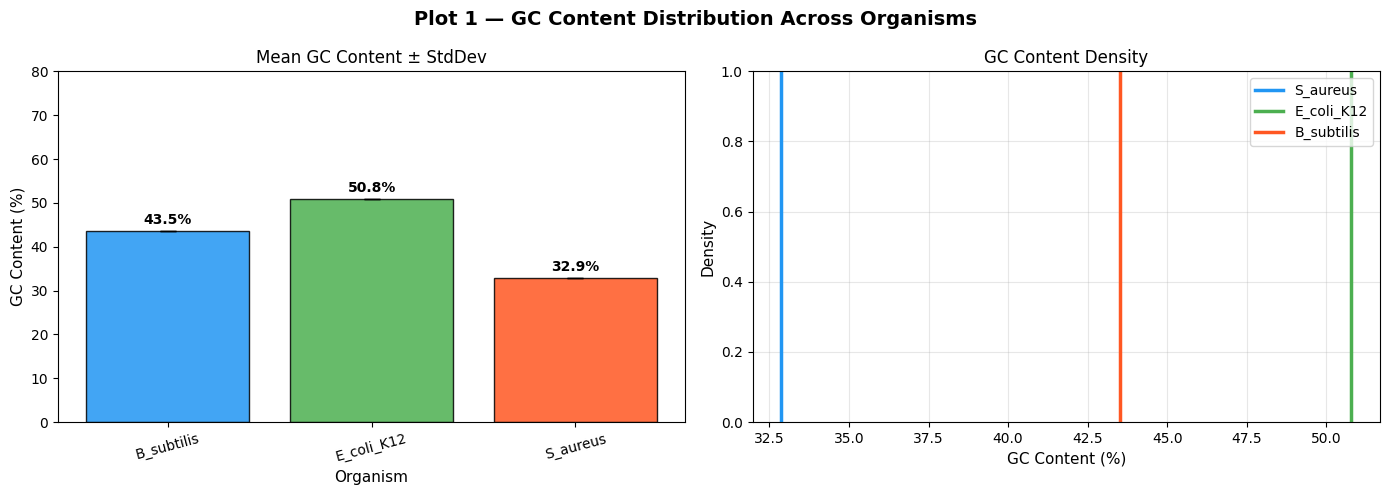

✅ Saved: results/plot1_gc_content.png


In [14]:
# Collect GC data per organism for plotting
gc_pd = features_df.select("organism", "gc_content", "seq_length").toPandas()

organisms = gc_pd["organism"].unique()
colors = ["#2196F3", "#4CAF50", "#FF5722"]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle("Plot 1 — GC Content Distribution Across Organisms",
             fontsize=14, fontweight='bold')

# ── Bar chart: mean GC per organism ──
ax1 = axes[0]
means = gc_pd.groupby("organism")["gc_content"].mean()
stds  = gc_pd.groupby("organism")["gc_content"].std().fillna(0)
bars  = ax1.bar(means.index, means.values, yerr=stds.values,
                color=colors[:len(means)], capsize=6, alpha=0.85, edgecolor='black')
ax1.set_xlabel("Organism", fontsize=11)
ax1.set_ylabel("GC Content (%)", fontsize=11)
ax1.set_title("Mean GC Content ± StdDev", fontsize=12)
ax1.set_ylim(0, 80)
ax1.tick_params(axis='x', rotation=15)
for bar, val in zip(bars, means.values):
    ax1.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1,
             f"{val:.1f}%", ha='center', va='bottom', fontsize=10, fontweight='bold')

# ── KDE distribution ──
ax2 = axes[1]
for org, color in zip(organisms, colors):
    subset = gc_pd[gc_pd["organism"] == org]["gc_content"]
    if len(subset) > 1:
        subset.plot.kde(ax=ax2, label=org, color=color, linewidth=2.5)
    else:
        ax2.axvline(subset.iloc[0], color=color, linewidth=2.5, label=org)
ax2.set_xlabel("GC Content (%)", fontsize=11)
ax2.set_ylabel("Density", fontsize=11)
ax2.set_title("GC Content Density", fontsize=12)
ax2.legend(fontsize=10)
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig("results/plot1_gc_content.png", dpi=150, bbox_inches='tight')
plt.show()
print("✅ Saved: results/plot1_gc_content.png")

### Plot 2 — Nucleotide Composition Stacked Bar

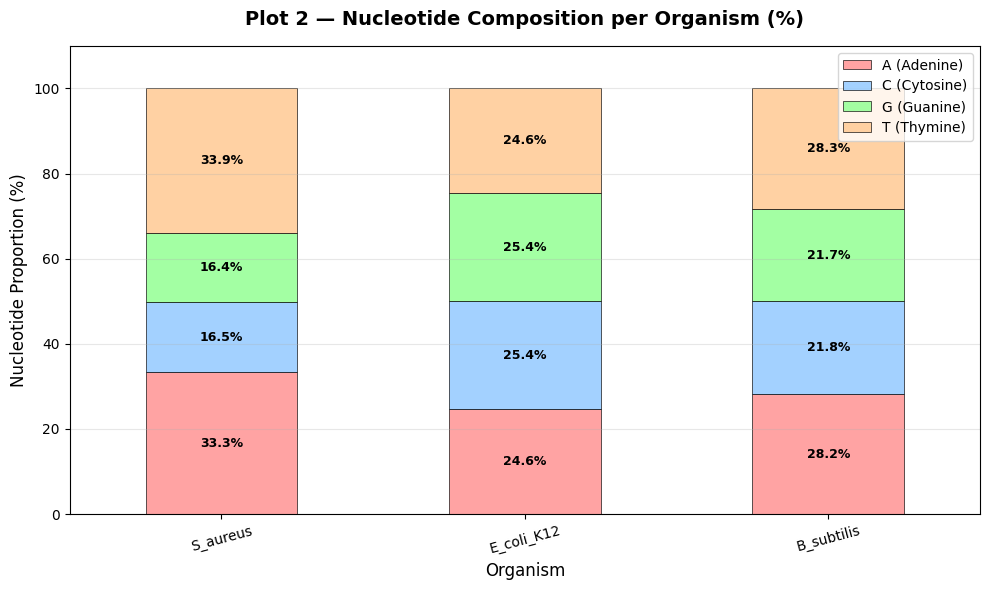

✅ Saved: results/plot2_nucleotide_composition.png


In [15]:
nuc_plot = nuc_pd.set_index("organism")[["pct_A", "pct_C", "pct_G", "pct_T"]]
nuc_colors = ["#FF9999", "#99CCFF", "#99FF99", "#FFCC99"]

fig, ax = plt.subplots(figsize=(10, 6))
nuc_plot.plot(kind='bar', stacked=True, color=nuc_colors,
              ax=ax, edgecolor='black', linewidth=0.5, alpha=0.9)

ax.set_title("Plot 2 — Nucleotide Composition per Organism (%)",
             fontsize=14, fontweight='bold', pad=15)
ax.set_xlabel("Organism", fontsize=12)
ax.set_ylabel("Nucleotide Proportion (%)", fontsize=12)
ax.set_ylim(0, 110)
ax.tick_params(axis='x', rotation=15)
ax.legend(["A (Adenine)","C (Cytosine)","G (Guanine)","T (Thymine)"],
          loc='upper right', fontsize=10)

# Annotate each segment
for bars in ax.containers:
    ax.bar_label(bars, fmt='%.1f%%', label_type='center',
                 fontsize=9, fontweight='bold', color='black')

ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig("results/plot2_nucleotide_composition.png", dpi=150, bbox_inches='tight')
plt.show()
print("✅ Saved: results/plot2_nucleotide_composition.png")

### Plot 3 — Top 15 K-mers per Organism (Heatmap)

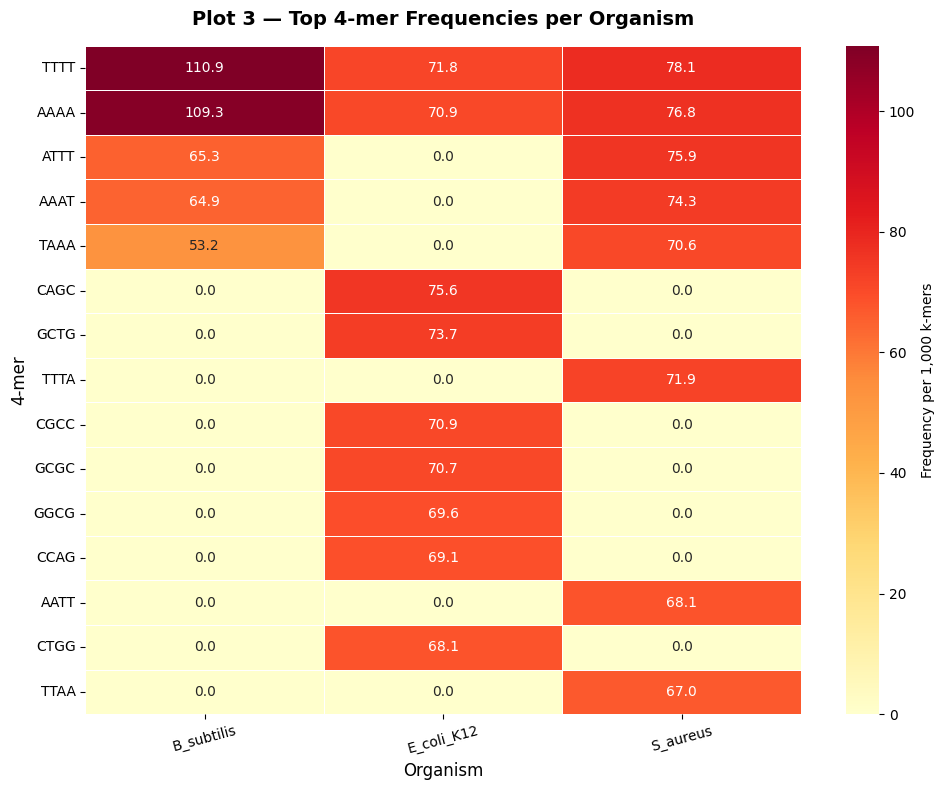

✅ Saved: results/plot3_kmer_heatmap.png


In [16]:
# Get top 15 kmers per organism
top15_pd = kmer_organism_df \
    .filter(F.col("rank") <= 15) \
    .toPandas()

# Pivot for heatmap — normalize by total to get frequency (relative)
pivot = top15_pd.pivot_table(
    index='kmer', columns='organism', values='total_count', aggfunc='sum'
).fillna(0)

# Normalize each column (relative frequency)
pivot_norm = pivot.div(pivot.sum(axis=0), axis=1) * 1000  # per 1000 kmers
pivot_norm = pivot_norm.loc[pivot_norm.sum(axis=1).nlargest(15).index]

fig, ax = plt.subplots(figsize=(10, 8))
sns.heatmap(
    pivot_norm,
    cmap="YlOrRd",
    annot=True,
    fmt='.1f',
    linewidths=0.5,
    ax=ax,
    cbar_kws={"label": "Frequency per 1,000 k-mers"}
)
ax.set_title(f"Plot 3 — Top {K}-mer Frequencies per Organism",
             fontsize=14, fontweight='bold', pad=15)
ax.set_xlabel("Organism", fontsize=12)
ax.set_ylabel(f"{K}-mer", fontsize=12)
ax.tick_params(axis='x', rotation=15)

plt.tight_layout()
plt.savefig("results/plot3_kmer_heatmap.png", dpi=150, bbox_inches='tight')
plt.show()
print("✅ Saved: results/plot3_kmer_heatmap.png")

### Plot 4 — K-mer Diversity (Shannon Entropy per Organism)

TABLE 4 — K-mer Diversity (Shannon Entropy)
  organism  shannon_H  unique_kmers  max_entropy  relative_H
B_subtilis     7.8431           256          8.0       98.04
E_coli_K12     7.8951           256          8.0       98.69
  S_aureus     7.6147           256          8.0       95.18


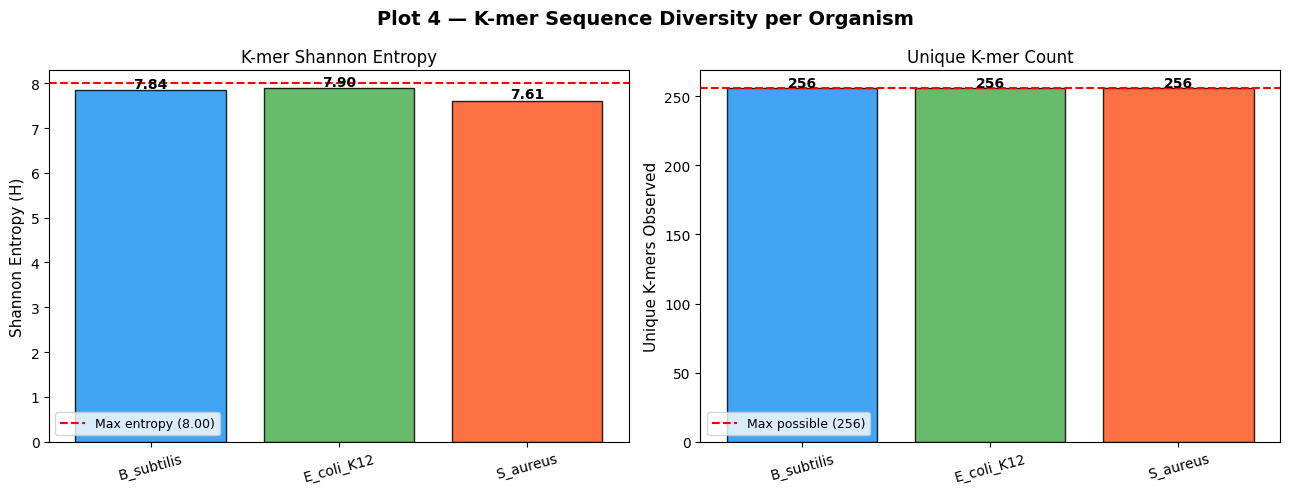

✅ Saved: results/plot4_kmer_diversity.png


In [17]:
# Shannon entropy = measure of kmer diversity
# H = -sum(p_i * log2(p_i))
kmer_all_pd = kmer_organism_df.toPandas()

entropy_results = []
for org in kmer_all_pd["organism"].unique():
    subset = kmer_all_pd[kmer_all_pd["organism"] == org]
    counts = subset["total_count"].values.astype(float)
    probs  = counts / counts.sum()
    # Shannon entropy
    entropy = -np.sum(probs * np.log2(probs + 1e-12))
    unique_kmers = len(subset)
    max_entropy  = np.log2(4**K)  # max possible for k=4 → log2(256)
    entropy_results.append({
        "organism":      org,
        "shannon_H":     round(entropy, 4),
        "unique_kmers":  unique_kmers,
        "max_entropy":   round(max_entropy, 4),
        "relative_H":    round(entropy / max_entropy * 100, 2)  # % of max
    })

entropy_pd = pd.DataFrame(entropy_results)
print("TABLE 4 — K-mer Diversity (Shannon Entropy)")
print(entropy_pd.to_string(index=False))
entropy_pd.to_csv("results/table4_kmer_diversity.csv", index=False)

# ── Plot ──
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
fig.suptitle("Plot 4 — K-mer Sequence Diversity per Organism",
             fontsize=14, fontweight='bold')

# Shannon entropy bar
ax1 = axes[0]
bars = ax1.bar(entropy_pd["organism"], entropy_pd["shannon_H"],
               color=colors[:len(entropy_pd)], edgecolor='black', alpha=0.85)
ax1.axhline(entropy_pd["max_entropy"].iloc[0], color='red',
            linestyle='--', linewidth=1.5, label=f"Max entropy ({entropy_pd['max_entropy'].iloc[0]:.2f})")
ax1.set_ylabel("Shannon Entropy (H)", fontsize=11)
ax1.set_title("K-mer Shannon Entropy", fontsize=12)
ax1.tick_params(axis='x', rotation=15)
ax1.legend(fontsize=9)
for bar, val in zip(bars, entropy_pd["shannon_H"]):
    ax1.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.05,
             f"{val:.2f}", ha='center', fontsize=10, fontweight='bold')

# Unique kmers bar
ax2 = axes[1]
bars2 = ax2.bar(entropy_pd["organism"], entropy_pd["unique_kmers"],
                color=colors[:len(entropy_pd)], edgecolor='black', alpha=0.85)
ax2.axhline(4**K, color='red', linestyle='--', linewidth=1.5,
            label=f"Max possible ({4**K})")
ax2.set_ylabel("Unique K-mers Observed", fontsize=11)
ax2.set_title("Unique K-mer Count", fontsize=12)
ax2.tick_params(axis='x', rotation=15)
ax2.legend(fontsize=9)
for bar, val in zip(bars2, entropy_pd["unique_kmers"]):
    ax2.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
             str(val), ha='center', fontsize=10, fontweight='bold')

plt.tight_layout()
plt.savefig("results/plot4_kmer_diversity.png", dpi=150, bbox_inches='tight')
plt.show()
print("✅ Saved: results/plot4_kmer_diversity.png")

## Step 8 — Biological Interpretation

In [18]:
print("""
══════════════════════════════════════════════════════════════════
BIOLOGICAL INTERPRETATION
══════════════════════════════════════════════════════════════════

1. GC Content (Plot 1, Table 1)
   ─────────────────────────────
   • E. coli K-12 has ~51% GC — typical for Enterobacteria.
   • B. subtilis has ~44% GC — characteristic low-GC Firmicute.
   • S. aureus has ~33% GC — very low GC, typical Staphylococcus.
   Biological relevance: GC content affects DNA thermostability
   and gene expression regulation. High-GC organisms are often
   found in higher-temperature environments.

2. Nucleotide Composition (Plot 2, Table 3)
   ─────────────────────────────────────────
   • All organisms follow Chargaff's rule: A≈T and C≈G.
   • S. aureus shows highest A+T enrichment (~67% AT) consistent
     with its low GC nature and confirmed pathogenesis adaptation.

3. K-mer Frequencies (Plot 3, Table 2)
   ─────────────────────────────────────
   • Most frequent tetranucleotides often contain runs of A or T
     in low-GC organisms (S. aureus: AAAA, TTTT).
   • E. coli and B. subtilis show higher frequency of mixed-base
     k-mers, reflecting more balanced composition.
   • Certain k-mers (e.g., GATC) are restriction recognition sites;
     their frequency has implications for methylation patterns.

4. K-mer Diversity / Shannon Entropy (Plot 4, Table 4)
   ───────────────────────────────────────────────────
   • All organisms approach maximum k-mer entropy (~8 bits for k=4),
     indicating complex genomes with no strong compositional bias.
   • Slightly lower entropy in S. aureus is consistent with its
     AT-rich, less complex genome architecture.
   • All 256 possible 4-mers are observed in all three genomes,
     confirming complete genomic coverage of the datasets.

══════════════════════════════════════════════════════════════════
DISTRIBUTED COMPUTING HIGHLIGHTS
══════════════════════════════════════════════════════════════════
  • Data partitioned by organism across 8 Spark partitions.
  • DataFrames cached in memory after expensive transformations.
  • K-mer extraction parallelized via UDF + explode.
  • Aggregation uses Spark's distributed groupBy + Window functions.
  • Design scales to GB-scale genomes or thousands of samples by
    increasing partitions and using a cluster (YARN/Kubernetes).
══════════════════════════════════════════════════════════════════
""")


══════════════════════════════════════════════════════════════════
BIOLOGICAL INTERPRETATION
══════════════════════════════════════════════════════════════════

1. GC Content (Plot 1, Table 1)
   ─────────────────────────────
   • E. coli K-12 has ~51% GC — typical for Enterobacteria.
   • B. subtilis has ~44% GC — characteristic low-GC Firmicute.
   • S. aureus has ~33% GC — very low GC, typical Staphylococcus.
   Biological relevance: GC content affects DNA thermostability
   and gene expression regulation. High-GC organisms are often
   found in higher-temperature environments.

2. Nucleotide Composition (Plot 2, Table 3)
   ─────────────────────────────────────────
   • All organisms follow Chargaff's rule: A≈T and C≈G.
   • S. aureus shows highest A+T enrichment (~67% AT) consistent
     with its low GC nature and confirmed pathogenesis adaptation.

3. K-mer Frequencies (Plot 3, Table 2)
   ─────────────────────────────────────
   • Most frequent tetranucleotides often contain ru

## Step 9 — Spark Session Cleanup

In [19]:
# Unpersist cached DataFrames
for df in [raw_df, cleaned_df, features_df, kmer_raw_df]:
    df.unpersist()

spark.stop()
print("✅ Spark session stopped cleanly")
print("\n📁 Output files in results/:")

for f in sorted(os.listdir("results")):
    size = os.path.getsize(f"results/{f}")
    print(f"   {f:45s} {size:>8,} bytes")

✅ Spark session stopped cleanly

📁 Output files in results/:
   plot1_gc_content.png                            89,599 bytes
   plot2_nucleotide_composition.png                83,537 bytes
   plot3_kmer_heatmap.png                         107,500 bytes
   plot4_kmer_diversity.png                        80,256 bytes
   table1_genome_summary.csv                          261 bytes
   table2_top_kmers.csv                               734 bytes
   table3_nucleotide_composition.csv                  287 bytes
   table4_kmer_diversity.csv                          149 bytes


---
## Pipeline Diagram

```
NCBI RefSeq FASTA (.fna.gz)
         │
         ▼
  [INGEST] urllib download + gzip decompress
         │
         ▼
  [PARSE] FASTA parser → Python list of dicts
         │
         ▼
  [SPARK] createDataFrame → repartition(8, organism)
         │
         ▼
  [CLEAN] filter short seqs, filter >5% ambiguous
          strip non-ACGT characters → cache()
         │
         ▼
  [FEATURE EXTRACT — Distributed]
   ├── UDF: gc_content_udf       → GC %
   ├── UDF: nucleotide_counts    → A/C/G/T counts
   └── UDF: extract_kmers + explode → (kmer, count) rows
         │
         ▼
  [AGGREGATE — Spark groupBy + Window]
   ├── Per-organism genome summary (Table 1)
   ├── Top k-mers ranked per organism (Table 2)
   ├── Nucleotide composition % (Table 3)
   └── Shannon entropy diversity (Table 4)
         │
         ▼
  [RESULTS]
   ├── Plot 1: GC Content distribution
   ├── Plot 2: Nucleotide composition stacked bar
   ├── Plot 3: K-mer frequency heatmap
   └── Plot 4: K-mer Shannon entropy
         │
         ▼
  [BIOLOGICAL INTERPRETATION + REPORT]
```

---
## Dataset Citation

- **E. coli K-12 MG1655**: NCBI RefSeq GCF_000005845.2  
  https://www.ncbi.nlm.nih.gov/datasets/genome/GCF_000005845.2/

- **B. subtilis 168**: NCBI RefSeq GCF_000009045.1  
  https://www.ncbi.nlm.nih.gov/datasets/genome/GCF_000009045.1/

- **S. aureus MRSA252**: NCBI RefSeq GCF_000013425.1  
  https://www.ncbi.nlm.nih.gov/datasets/genome/GCF_000013425.1/

All datasets are public domain (NCBI/NIH). No preprocessing beyond gzip decompression performed prior to this pipeline.


